# Look at Mackenzie River runoff climatology used in model

In [22]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

## import ECCO utils
import sys
sys.path.append('/Users/mzahn/github_others/ECCOv4-py')
import ecco_v4_py as ecco

[Fekete et al. (2002) paper](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/1999GB001254)
[Link to datasets](https://www.compositerunoff.sr.unh.edu/html/Data/index.html)

In [333]:
# define directory for runoff file
fdir = '/Users/mzahn/data/SASSIE/model/input/'
fname = 'runoff1p2472-360x180x12.bin'
num_cols = 180
num_rows = 360

In [335]:
# open .bin file
runoff_bin = ecco.load_binary_array(fdir, fname, ni=num_rows, nj=num_cols, nk=12, nl=1, skip=0,\
                                    filetype = '>f', less_output = False )

load_binary_array: loading file /Users/mzahn/data/SASSIE/model/input/runoff1p2472-360x180x12.bin
load_binary_array: data array shape  (12, 180, 360)
load_binary_array: data array type  >f4


In [114]:
# look at shape
runoff_bin.shape

(12, 180, 360)

In [116]:
12*180*360 # correct shape of data

777600

In [126]:
np.max(runoff_bin)

743.208

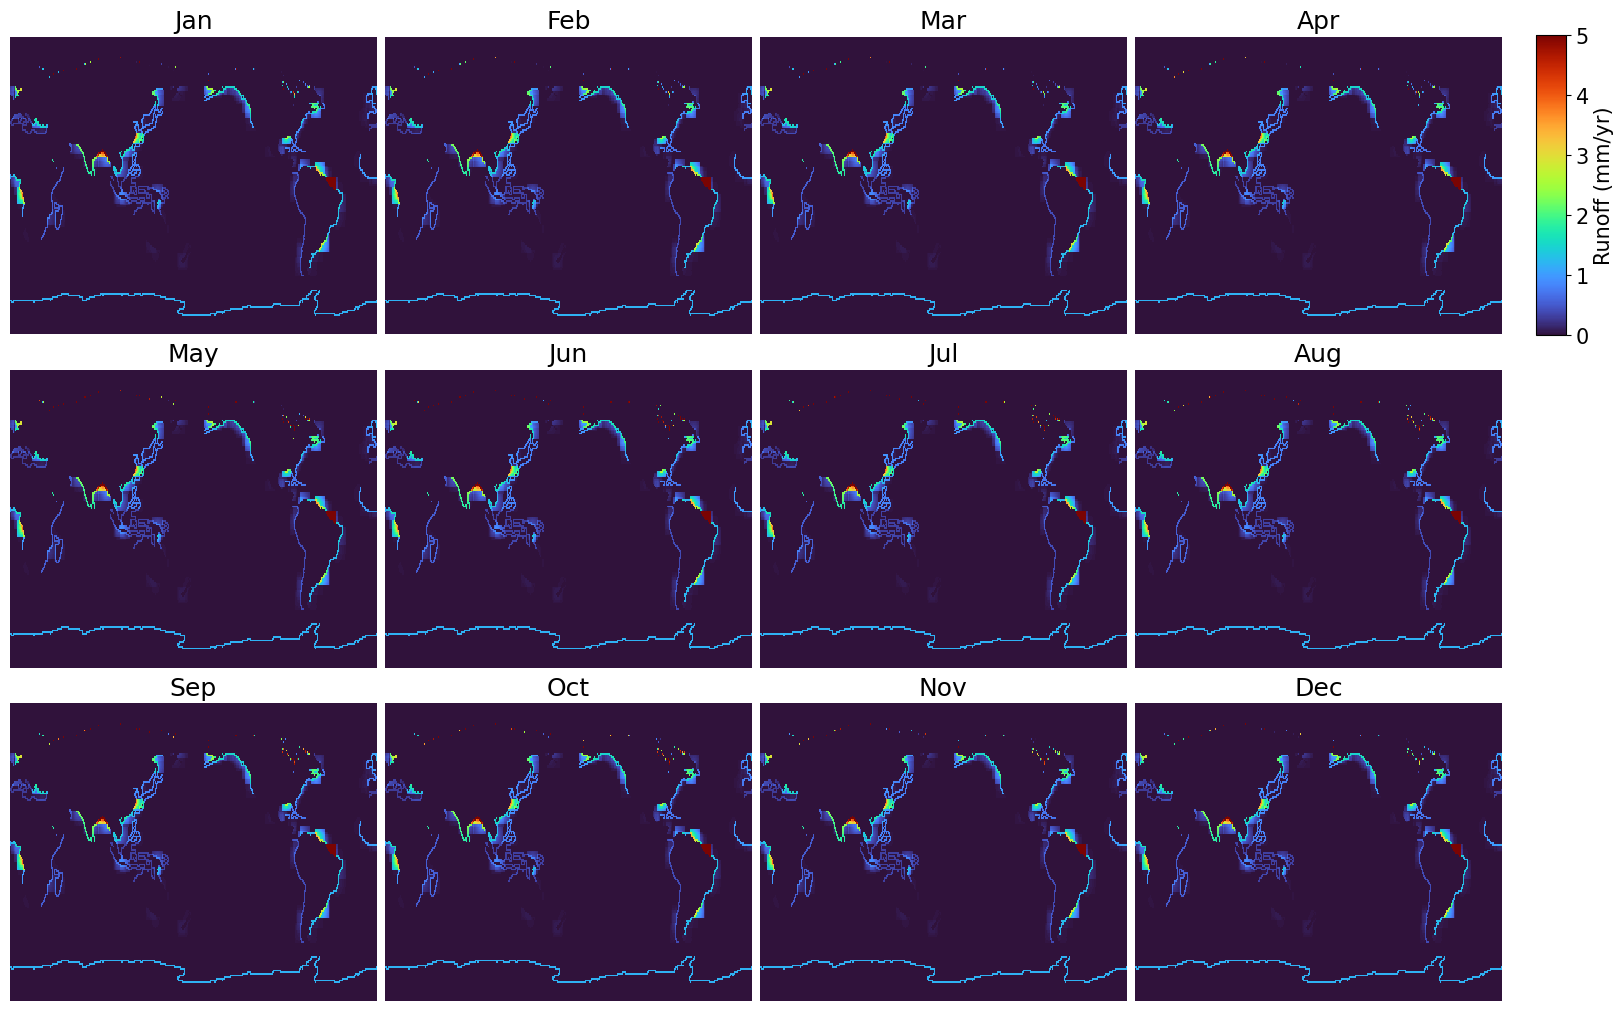

In [497]:
plt.rcParams['font.size'] = 15
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Define a colormap range
vmin, vmax = 0, 5

for i, ax in enumerate(axes.flat):
    im = ax.pcolormesh(runoff_bin[i], vmin=vmin, vmax=vmax, cmap='turbo')
    ax.set_title(months[i])
    ax.axis("off")  # Remove axis ticks

# Add a single colorbar to the right of all subplots
cbar_ax = fig.add_axes([1.02, 0.67, 0.02, 0.3])  # Position: [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Runoff (mm/yr)")

plt.show()

### Zoom into Mackenzie River discharge

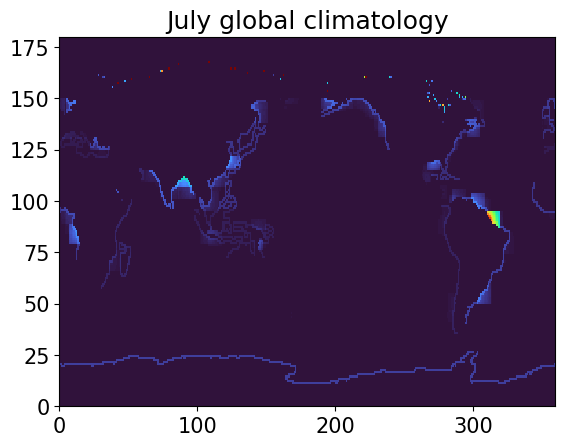

In [504]:
# first plot entire globe
plt.pcolormesh(runoff_bin[6], vmin=0, vmax=20, cmap='turbo');
plt.title('July global climatology');

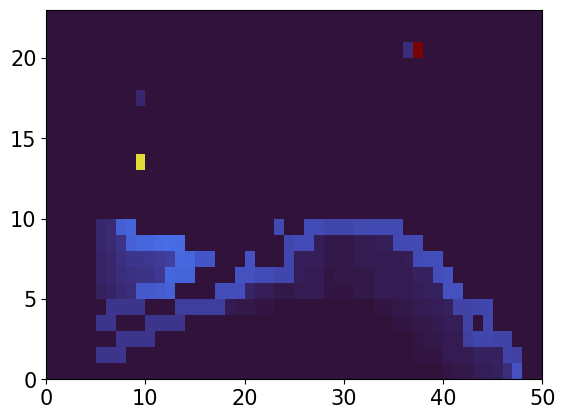

In [171]:
# zoom into Alaska
plt.pcolormesh(runoff_bin[0][140:163,185:235], vmin=0, vmax=20, cmap='turbo');

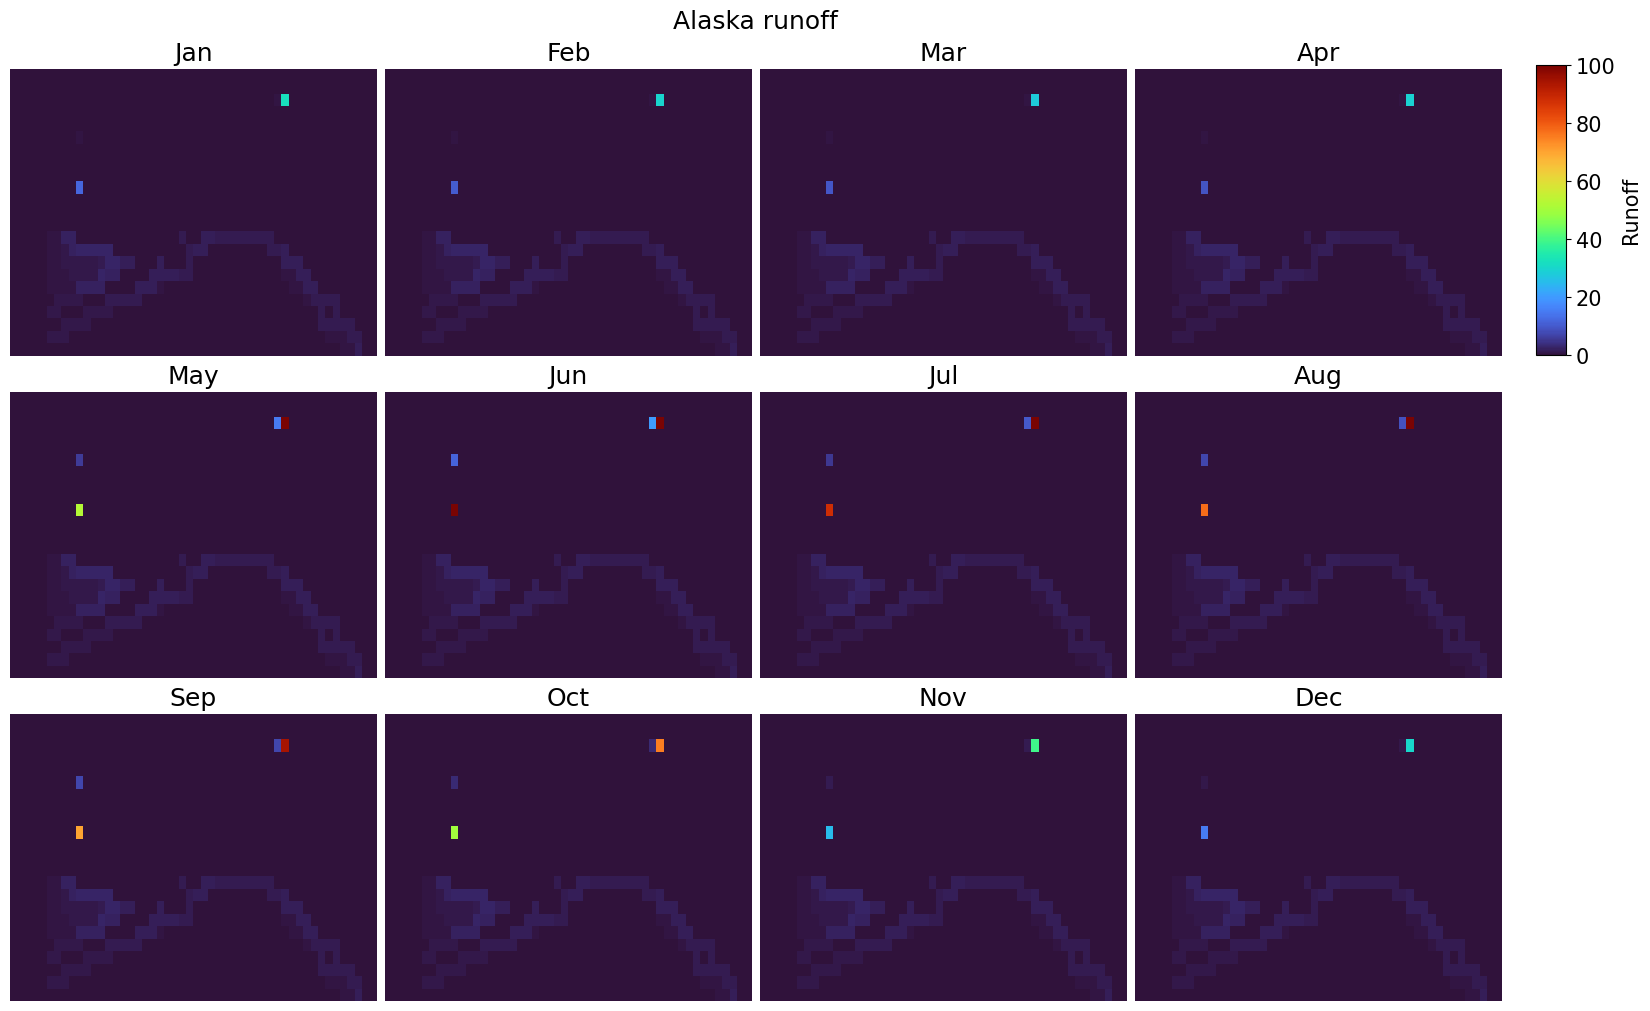

In [205]:
plt.rcParams['font.size'] = 15
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Define a colormap range
vmin, vmax = 0, 100

for i, ax in enumerate(axes.flat):
    im = ax.pcolormesh(runoff_bin[i][140:163,185:235], vmin=vmin, vmax=vmax, cmap='turbo')
    ax.set_title(months[i])
    ax.axis("off")  # Remove axis ticks

plt.suptitle('Alaska runoff')

# Add a single colorbar to the right of all subplots
cbar_ax = fig.add_axes([1.02, 0.65, 0.02, 0.29])  # Position: [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Runoff")

plt.show()

## Make a dataset and isolate Mackenzie River runoff

In [514]:
runoff_ds = xr.DataArray(
    data=runoff_bin,
    dims=["month", "j", "i"],
    coords=dict(
        month=np.arange(1,13,1),
        j=np.arange(0,180,1),
        i=np.arange(0,360,1),
    ),
    attrs=dict(
        description="Runoff",
        units="mm/mon",
    ),
)

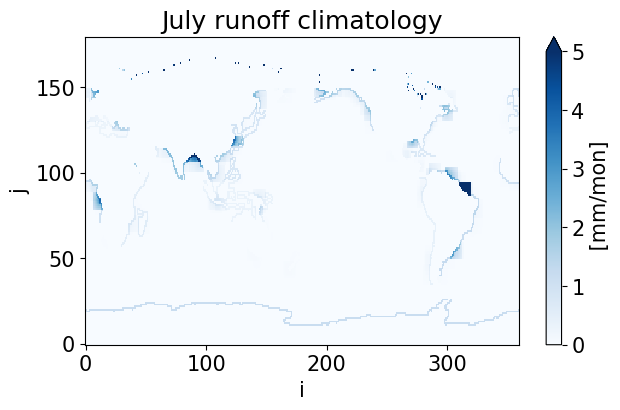

In [540]:
runoff_ds.isel(month=6).plot(vmin=0,vmax=5,cmap='Blues',figsize=[7,4]);
plt.title('July runoff climatology');

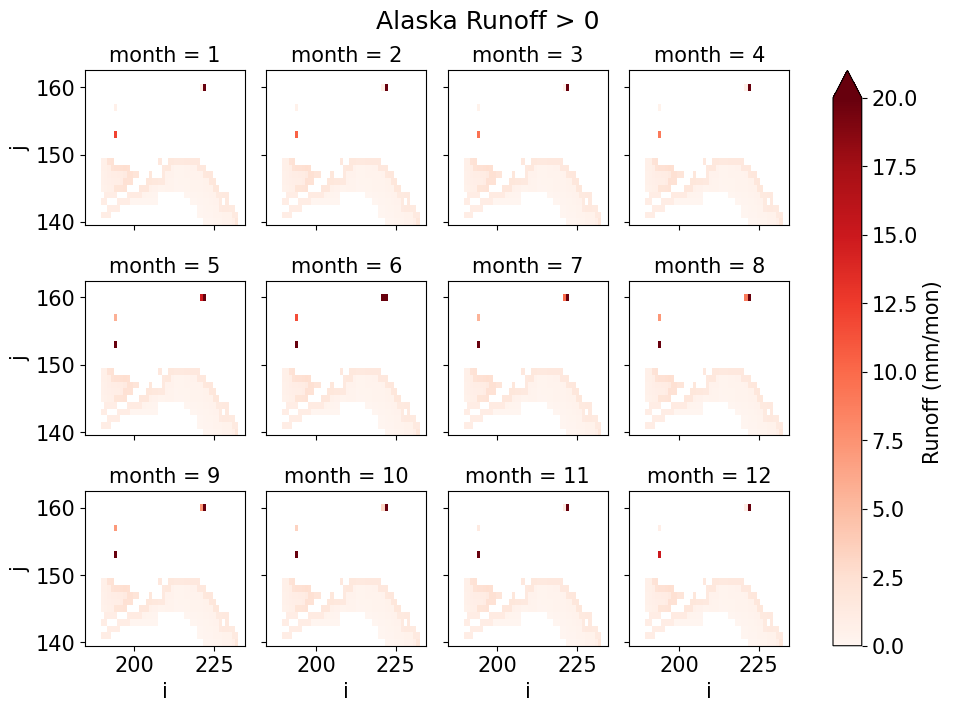

In [550]:
plt.rcParams['font.size'] = 15
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Select the subset region (i=140:163, j=185:235)
# runoff_subset = runoff_ds.where(runoff_ds>0).isel(i=slice(220,225),j=slice(155,163))
runoff_subset = runoff_ds.where(runoff_ds>0).isel(i=slice(185,235),j=slice(140,163))

# Plot using xarray's built-in facet plotting
runoff_subset.plot(col="month", col_wrap=4, cmap="Reds", 
                          vmin=0, vmax=20, figsize=(10, 7),
                          cbar_kwargs={"label": r"Runoff (mm/mon)"})

plt.suptitle('Alaska Runoff > 0', fontsize=18, y=1.02)
plt.show()

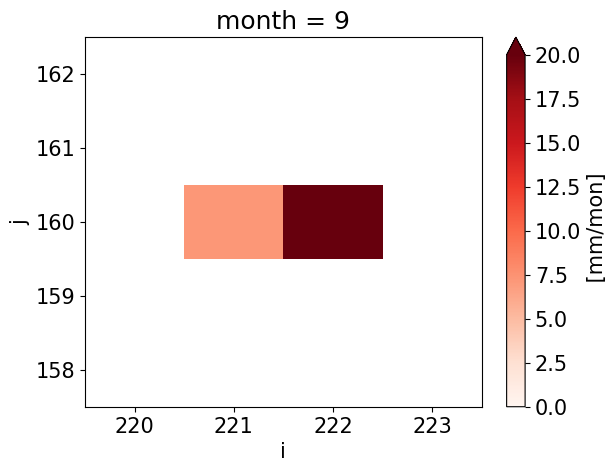

In [560]:
runoff_ds.where(runoff_ds>0).isel(month=8,i=slice(220,224),j=slice(158,163)).plot(vmin=0,vmax=20, cmap="Reds");

In [584]:
runoff_total_mmpermon = runoff_ds.isel(i=slice(221,223),j=160).sum(dim='i')

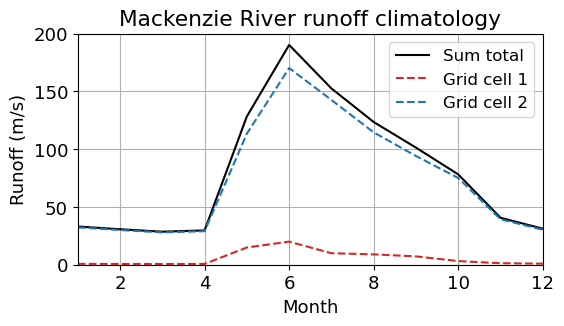

In [640]:
plt.rcParams['font.size'] = 13
# select two grid cells dedicated to Mackenzie River outflow
runoff_total_mmpermon.plot(color='k',figsize=[6,3],label='Sum total'); # we can sum them because they are the same area grid cells
runoff_ds.isel(i=221,j=160).plot(color='tab:red',linestyle='dashed',label='Grid cell 1')
runoff_ds.isel(i=222,j=160).plot(color='tab:blue',linestyle='dashed',label='Grid cell 2')
plt.title('Mackenzie River runoff climatology')
plt.legend(fontsize=12)
plt.ylim(0,200)
plt.xlim(1,12)
plt.grid()
plt.ylabel(r'Runoff (m/s)')
plt.xlabel('Month');

### Convert to m3/s

In [572]:
R = 6371  # radius of Earth in km
latitudes = np.linspace(-90, 90, 180)
longitudes = np.linspace(-180, 180, 360) 

# create a meshgrid for latitudes and longitudes
lat_grid, lon_grid = np.meshgrid(latitudes, longitudes)

# calculate the distance for each degree of latitude (constant for each degree of latitude)
lat_distance = (2 * np.pi * 6378) / 360 # total circumference (2*pi*R) divided by 360
print(lat_distance)

111.31709969219834


In [576]:
# calculate distance for each degree of longitude, varies with latitude
lon_distance = lat_distance * np.cos(np.deg2rad(lat_grid))  # in km

# Calculate the area for each grid cell
cell_area = lat_distance * lon_distance  # km^2

In [578]:
cell_area_da = xr.DataArray(
    cell_area,
    coords=[("longitude", longitudes), ("latitude", latitudes)],
    name="cell_area"
)

In [602]:
grid_area_m2 = cell_area_da.isel(longitude=slice(221,223),latitude=160).values[0] * 1e6

In [590]:
runoff_mackenzie = runoff_ds.isel(i=slice(221,223),j=160)

In [644]:
# m/s * m2
runoff_m3pers = runoff_mackenzie * grid_area_m2

In [648]:
# # num seconds in each month
# sec_per_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]) * 24 * 60 * 60

# # Create a DataArray
# sec_per_month = xr.DataArray(
#     sec_per_month,
#     dims=["month"],
#     coords={"month": np.arange(1, 13)},
#     name="seconds_per_month"
# )

sec_per_yr = 365 * 24 * 60 * 60

# runoff_m3pers = runoff_m3permon / sec_per_month
runoff_m3pers = runoff_m3permon / sec_per_yr

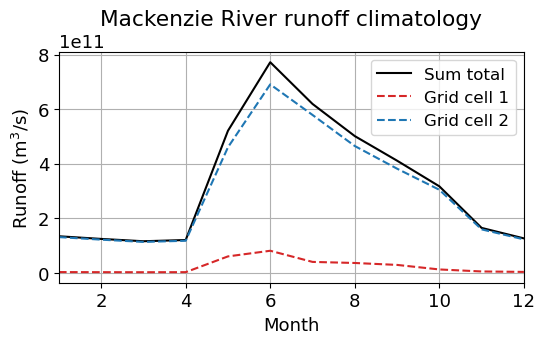

In [646]:
plt.rcParams['font.size'] = 13
# select two grid cells dedicated to Mackenzie River outflow
runoff_m3pers.sum(dim='i').plot(color='k',figsize=[6,3],label='Sum total'); # we can sum them because they are the same area grid cells
runoff_m3pers.isel(i=0).plot(color='tab:red',linestyle='dashed',label='Grid cell 1')
runoff_m3pers.isel(i=1).plot(color='tab:blue',linestyle='dashed',label='Grid cell 2')
plt.title('Mackenzie River runoff climatology')
plt.legend(fontsize=12)
# plt.ylim(0,200)
plt.xlim(1,12)
plt.grid()
plt.ylabel(r'Runoff (m$^3$/s)')
plt.xlabel('Month');